In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.rcParams['figure.dpi'] = 150

In [ ]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015 (1).csv')

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri:\n{', '.join(df.columns.tolist())}")
print(f"\nSınıf dağılımı ('Diabetes_012'):")
print(df['Diabetes_012'].value_counts().to_string())
print(f"\nİlk 5 satır:")
display(df.head())
print(f"\nVeri seti istatistikleri:")
display(df.describe())
print(f"\nEksik veri kontrolü:")
print(df.isnull().sum().to_string())

Veri seti boyutu: 253680 satır, 22 sütun

Sütun isimleri:
Diabetes_012, HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income

Sınıf dağılımı ('Diabetes_012'):
Diabetes_012
0.0    213703
2.0     35346
1.0      4631

İlk 5 satır:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Veri seti istatistikleri:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000



Eksik veri kontrolü:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0


In [ ]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")
print(f"\nÖzellikler: {X.columns.tolist()}")

Özellik matrisi (X): (253680, 21)
Hedef vektör (y):   (253680,)

Özellikler: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti:   {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:\n{y_train.value_counts().to_string()}")
print(f"\nTest seti sınıf dağılımı:\n{y_test.value_counts().to_string()}")

Eğitim seti: 202944 örnek
Test seti:   50736 örnek

Eğitim seti sınıf dağılımı:
Diabetes_012
0.0    170962
2.0     28277
1.0      3705

Test seti sınıf dağılımı:
Diabetes_012
0.0    42741
2.0     7069
1.0      926


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikler standardize edildi (mean=0, std=1)")
print(f"\nEğitim seti ilk satır (ölçeklenmiş):")
print(np.round(X_train_scaled[0], 3))

Özellikler standardize edildi (mean=0, std=1)

Eğitim seti ilk satır (ölçeklenmiş):
[ 1.153 -0.858  0.197 -0.513 -0.894 -0.206 -0.323  0.567  0.759  0.482
 -0.243  0.227 -0.302 -0.478 -0.429 -0.486 -0.45   1.129  0.643 -1.065
 -0.991]


In [ ]:
model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
model.fit(X_train_scaled, y_train)
print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


In [ ]:
model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
model.fit(X_train_scaled, y_train)
print("Model eğitimi tamamlandı.")

print(f"Kesişim (bias - β₀): {model.intercept_[0]:.4f}")
print(f"\nKatsayılar (β₁ ... βₙ):")
coef_df = pd.DataFrame({
    'Özellik': X.columns,
    'Katsayı': model.coef_[0],
    '|Katsayı|': np.abs(model.coef_[0])
}).sort_values('|Katsayı|', ascending=False)
display(coef_df)

Model eğitimi tamamlandı.
Kesişim (bias - β₀): 2.1643

Katsayılar (β₁ ... βₙ):


,Özellik,Katsayı,|Katsayı|
13,GenHlth,-0.309657,0.309657
18,Age,-0.253105,0.253105
3,BMI,-0.252392,0.252392
1,HighChol,-0.193894,0.193894
0,HighBP,-0.187704,0.187704
2,CholCheck,-0.129912,0.129912
20,Income,0.084474,0.084474
10,HvyAlcoholConsump,0.072863,0.072863
17,Sex,-0.060656,0.060656
15,PhysHlth,0.039141,0.039141


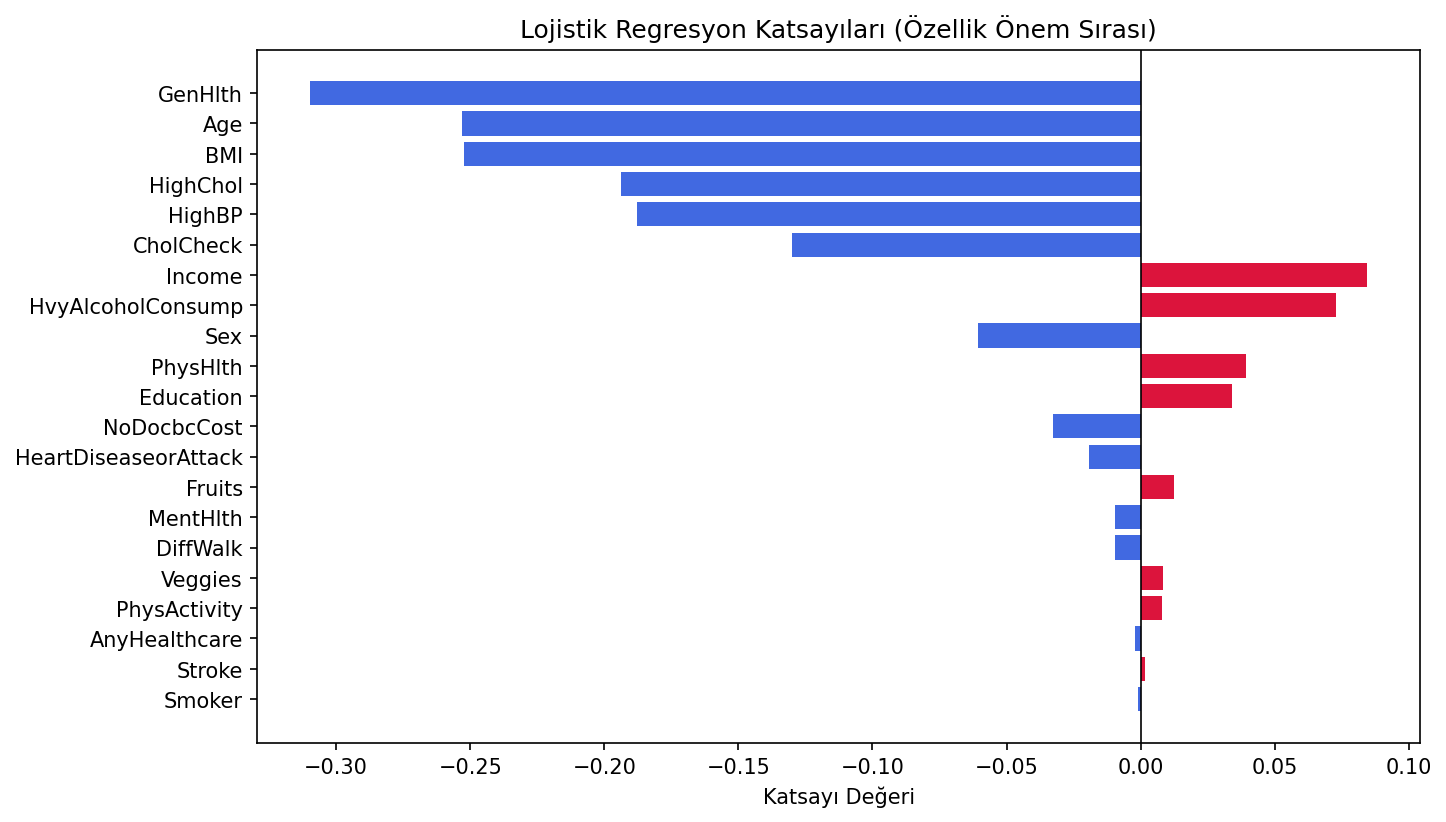

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['crimson' if c > 0 else 'royalblue' for c in coef_df['Katsayı']]
plt.barh(coef_df['Özellik'], coef_df['Katsayı'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Katsayı Değeri')
plt.title('Lojistik Regresyon Katsayıları (Özellik Önem Sırası)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')

print("=== MODEL PERFORMANS METRİKLERİ ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  AUC-ROC:                 {auc_roc:.4f}")

=== MODEL PERFORMANS METRİKLERİ ===
  Doğruluk (Accuracy):     0.8455  (84.55%)
  Hassasiyet (Precision):  0.7977  (79.77%)
  Duyarlılık (Recall):     0.8455  (84.55%)
  F1-Skoru:                0.8069
  AUC-ROC:                 0.7808


In [ ]:
cm = confusion_matrix(y_test, y_pred)


class_names = ["Diyabet Yok (0)", "Prediyabet (1)", "Diyabet Var (2)"]

print("=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===")

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df.to_string())

print("=== SINIFLANDIRMA RAPORU ===")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===
                 Diyabet Yok (0)  Prediyabet (1)  Diyabet Var (2)
Diyabet Yok (0)            41667               0             1074
Prediyabet (1)               839               0               87
Diyabet Var (2)             5840               0             1229
=== SINIFLANDIRMA RAPORU ===
                 precision    recall  f1-score   support

Diyabet Yok (0)       0.86      0.97      0.91     42741
 Prediyabet (1)       0.00      0.00      0.00       926
Diyabet Var (2)       0.51      0.17      0.26      7069

       accuracy                           0.85     50736
      macro avg       0.46      0.38      0.39     50736
   weighted avg       0.80      0.85      0.81     50736



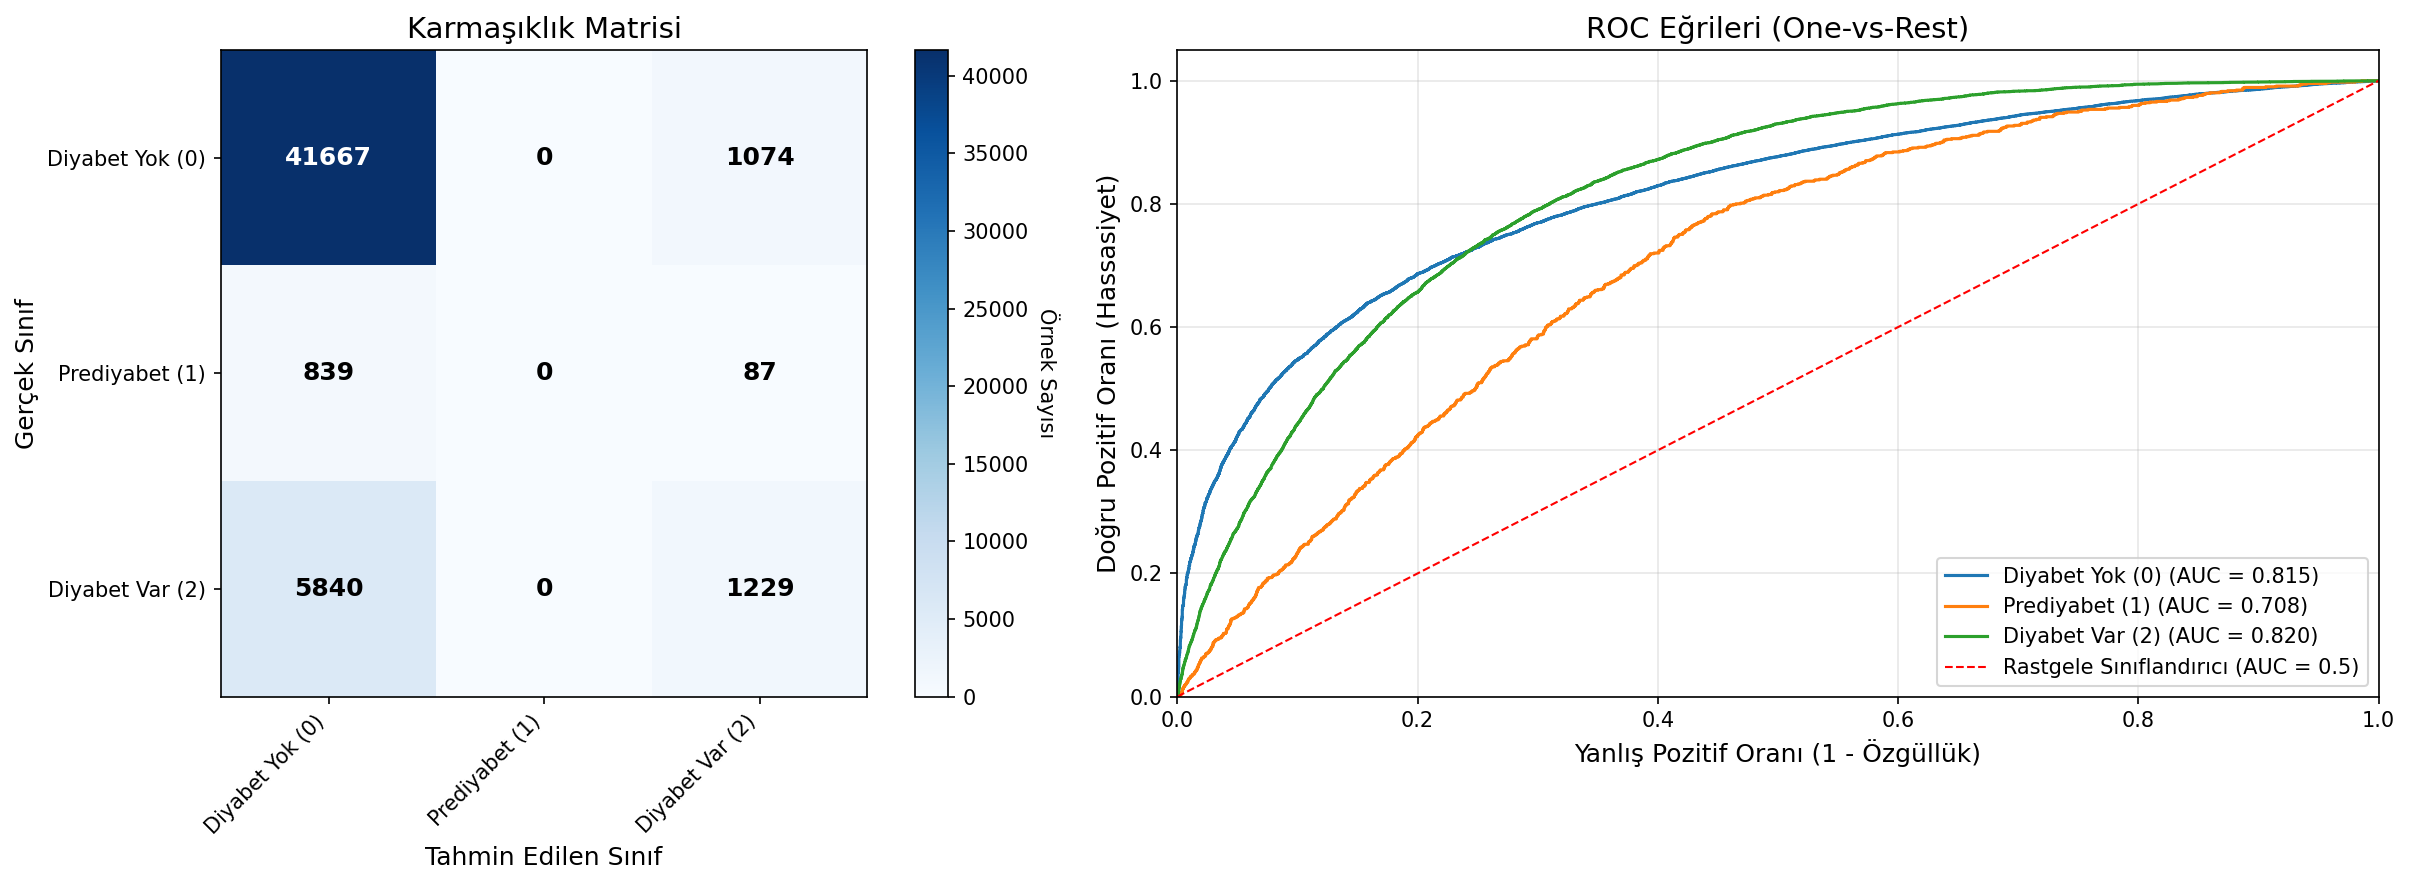

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))


im = ax[0].imshow(cm, cmap='Blues')


ax[0].set_xticks(np.arange(len(class_names)))
ax[0].set_yticks(np.arange(len(class_names)))
ax[0].set_xticklabels(class_names, rotation=45, ha="right")
ax[0].set_yticklabels(class_names)


for i in range(len(class_names)):
    for j in range(len(class_names)):
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax[0].text(j, i, cm[i, j], ha="center", va="center", color=text_color, fontsize=12, fontweight='bold')

ax[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
ax[0].set_ylabel('Gerçek Sınıf', fontsize=12)
ax[0].set_title('Karmaşıklık Matrisi', fontsize=14)


cbar = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label('Örnek Sayısı', rotation=270, labelpad=15)


for i, class_name in enumerate(class_names):
    y_true_binary = (y_test == i).astype(int)
    y_score_class_i = y_pred_proba[:, i]


    if y_true_binary.sum() > 0:
        fpr, tpr, _ = roc_curve(y_true_binary, y_score_class_i)
        auc_score_class_i = roc_auc_score(y_true_binary, y_score_class_i)
        ax[1].plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score_class_i:.3f})')
    else:
        print(f"Uyarı: '{class_name}' sınıfı için ROC eğrisi çizilemedi (test setinde örnek yok).")

ax[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Rastgele Sınıflandırıcı (AUC = 0.5)')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Yanlış Pozitif Oranı (1 - Özgüllük)', fontsize=12)
ax[1].set_ylabel('Doğru Pozitif Oranı (Hassasiyet)', fontsize=12)
ax[1].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=14)
ax[1].legend(loc='lower right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
sample_proba = model.predict_proba(sample_scaled)[0, 1]
sample_pred = model.predict(sample_scaled)[0]

print("Örnek hasta verisi:")
display(sample)
print(f"\nPrediyabet olasılığı: {sample_proba:.4f} ({sample_proba*100:.1f}%)")
print(f"Tahmin: {sample_pred} ({"Diyabet Yok" if sample_pred == 0.0 else "Prediyabet" if sample_pred == 1.0 else "Diyabet Var"})")
print(f"Gerçek: {y_test.iloc[0]}")

Örnek hasta verisi:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
167906,0.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,3.0,2.0,0.0,0.0,1.0,5.0,6.0,7.0



Prediyabet olasılığı: 0.0138 (1.4%)
Tahmin: 0.0 (Diyabet Yok)
Gerçek: 0.0


In [ ]:
print("=== SONUÇ TABLOSU ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  AUC-ROC:                 {auc_roc:.4f}")

=== SONUÇ TABLOSU ===
  Doğruluk (Accuracy):     0.8455  (84.55%)
  Hassasiyet (Precision):  0.7977  (79.77%)
  Duyarlılık (Recall):     0.8455  (84.55%)
  F1-Skoru:                0.8069
  AUC-ROC:                 0.7808
